In [2]:
## Imports
import time
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio
import importlib

from mocpy import WCS as MOCWCS
from mocpy import MOC
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.io import fits
from astropy.table import Table

import src.statistics.corrutils as cu

In [4]:
mocfiles = glob.glob(
            f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc*.fits'
        )
mocpath = str(mocfiles[1])
print(Path(mocpath).resolve().stem)
moc = MOC.from_fits(mocpath)

output_dir = '.'
t = 'ELGnotqso'
nproc = 1
sample_rate_desi = 1
sample_rate_hsc = 1
bin1 = cu.CorrelationMeta.bins_elg
bin2 = cu.CorrelationMeta.bins_hsc

hsc_moc1


In [5]:
import logging
logger = logging.getLogger(__name__)

In [124]:
importlib.reload(cu)
cc = cu.CrossCorrelation(
        t, 
        moc, 
        output_dir,
        bin_distances=cu.bin_distances,
        bin_redshift1=bin1,
        bin_redshift2=bin2, 
        nproc=nproc, 
        sample_rate_desi=sample_rate_desi,
        sample_rate_hsc=sample_rate_hsc, 
        logger=logger,
    )

Filtering 25879693 randoms in /global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_7_clustering.ran.fits using MOC
Filtering 25878825 randoms in /global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_1_clustering.ran.fits using MOC
Filtering 25877963 randoms in /global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_6_clustering.ran.fits using MOC
Filtering 25880985 randoms in /global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_14_clustering.ran.fits using MOC
Filtering 25878470 randoms in /global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_4_clustering.ran.fits using MOC
Filtered in 4.33 seconds
Filtered in 4.91 seconds
Filtered in 4.36 seconds
Filtered in 5.10 seconds
Filtered in 4.97 seconds
Processed 5 random files in 42.65 seconds
Collated 3295056 randoms (from 5 files)
Filtering 10800701 randoms in /global/cfs/

In [127]:
len(cc.data2)

14719437

In [84]:
desi = fio.FITS(cc.fetch_desi_files()[0])
desi = fio.FITS('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_7_clustering.ran.fits')
coords_desi_file = desi[1].read(columns=['RA', 'DEC'])
coords_desi = SkyCoord(
    ra=coords_desi_file['RA'] * u.deg,
    dec=coords_desi_file['DEC'] * u.deg,
    frame='icrs'
)

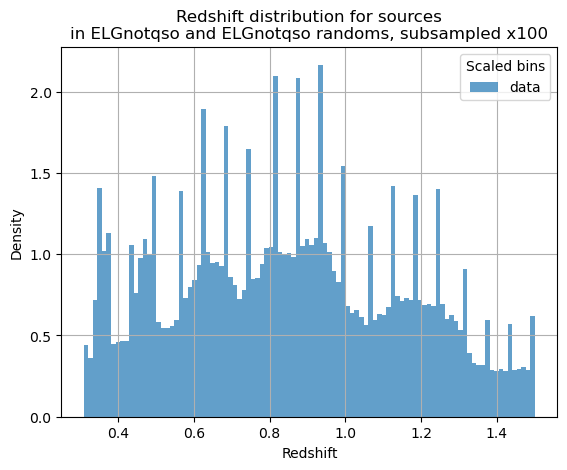

In [129]:
#plt.hist(cc.randoms1['Z'][0::100], bins=100, label='randoms', alpha=0.7, density=True)
plt.hist(cc.data2['dnnz_photoz_best'][0::100], bins=100, label='data', alpha=0.7, density=True)
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.legend(loc='upper right', title='Scaled bins')
plt.title(f'Redshift distribution for sources\nin {t} and {t} randoms, subsampled x100')
plt.grid()

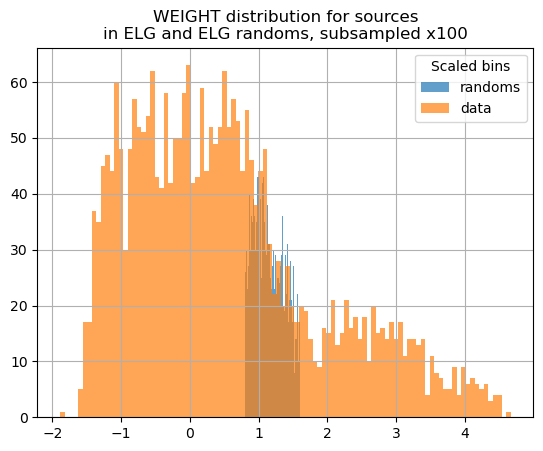

In [97]:
plt.hist(cc.randoms1['WEIGHT'][0::100], bins=int(len(cc.randoms1)/len(cc.data1))*100, label='randoms', alpha=0.7)
plt.hist(cc.data1['WEIGHT'][0::100], bins=100, label='data', alpha=0.7)
plt.legend(loc='upper right', title='Scaled bins')
plt.title('WEIGHT distribution for sources\nin ELG and ELG randoms, subsampled x100')
plt.grid()

Number of DESI targets in MOC: 658750
Number of DESI targets: 25879693
Percentage of DESI targets in MOC: 2.55%


Text(0.5, 1.0, 'HSC-DESI targets on MOCs')

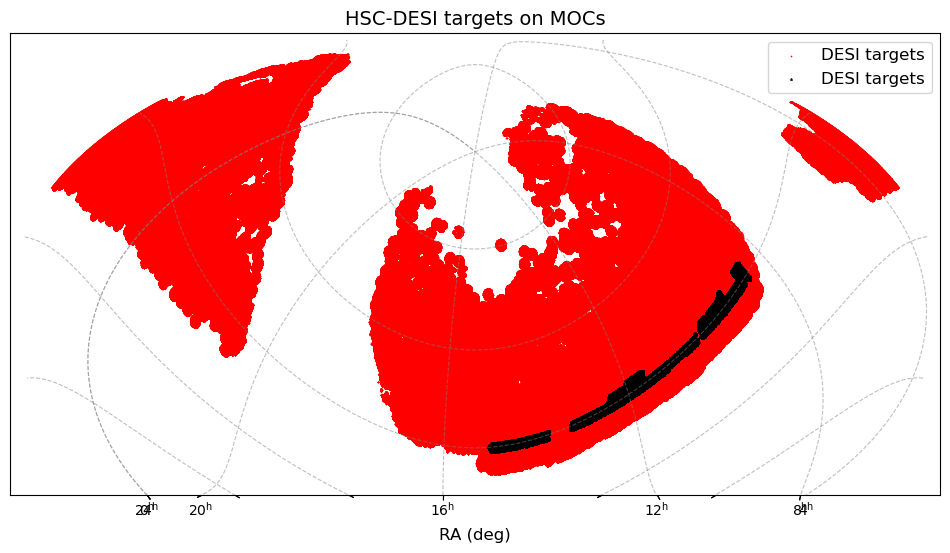

In [85]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=10 * u.deg,
           center=SkyCoord(230, 44, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

lon_desi, lat_desi = coords_desi.ra.wrap_at(180 * u.deg).degree, coords_desi.dec.degree

desi_in_moc_n = np.zeros(len(coords_desi), dtype=bool)

desi_in_moc_n = moc.contains_skycoords(coords_desi)
moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

desi_in_moc = desi[1].read(rows=np.flatnonzero(desi_in_moc_n), columns=['RA', 'DEC'])
coords_desi_in_moc = SkyCoord(desi_in_moc['RA'], desi_in_moc['DEC'], unit='deg', frame='icrs')
lon_desi_in_moc, lat_desi_in_moc = coords_desi_in_moc.ra.wrap_at(180 * u.deg).degree, coords_desi_in_moc.dec.degree

print(f'Number of DESI targets in MOC: {len(desi_in_moc)}')
print(f'Number of DESI targets: {len(coords_desi)}')
print(f'Percentage of DESI targets in MOC: {len(desi_in_moc) / len(coords_desi) * 100:.2f}%')

ax.scatter(
    lon_desi, 
    lat_desi,
    transform=tr,
    marker='v',
    s=0.05,
    color='red', 
    alpha=1,
    label='DESI targets'
    )

ax.scatter(
    lon_desi_in_moc, 
    lat_desi_in_moc,
    transform=tr,
    marker='^',
    s=1,
    color='black', 
    alpha=1,
    label='DESI targets'
    )

ax.grid(color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=12)
ax.set_xlabel('RA (deg)', fontsize=12)
ax.set_ylabel('Dec (deg)', fontsize=12)
ax.set_title('HSC-DESI targets on MOCs', fontsize=14)

## MOC Status

Text(0.5, 1.0, 'Redshift distribution for sources\nin ELG and ELG randoms, subsampled x100')

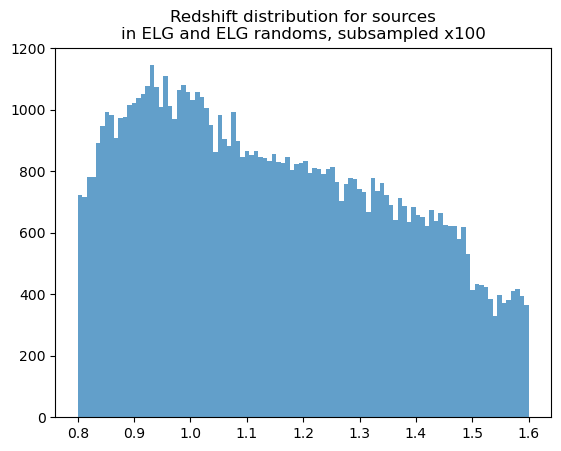

In [106]:
file = Path('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits')
elgz = fio.FITS(file)
z = elgz[1].read(columns=['Z'])
plt.hist(z['Z'][0::100], bins=100, label='data', alpha=0.7)
plt.title('Redshift distribution for sources\nin ELG and ELG randoms, subsampled x100')

Text(0.5, 1.0, 'Redshift distribution for sources\nin ELG and ELG randoms, subsampled x100')

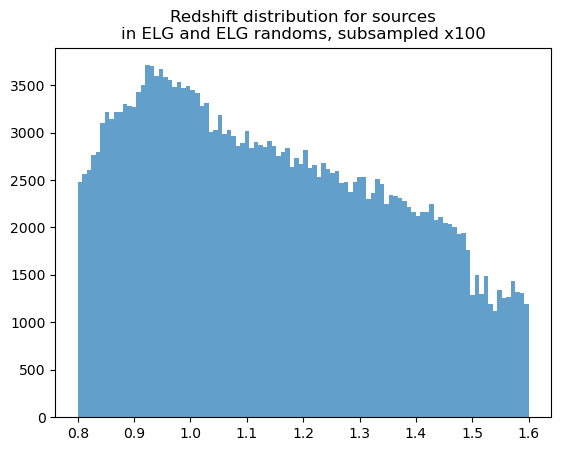

In [107]:
file = Path('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_7_clustering.ran.fits')
elgz = fio.FITS(file)
z = elgz[1].read(columns=['Z'])
plt.hist(z['Z'][0::100], bins=100, label='data', alpha=0.7)
plt.title('Redshift distribution for sources\nin ELG and ELG randoms, subsampled x100')